In [ ]:
import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [46]:
modelling_data = pd.read_csv("../customer_data/artifacts/customer_profile_data.csv")
modelling_data.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,CustomerDOB,CustGender,CustLocation,Age,LastAccountBalance,FirstAccountBalance,AvgAccountBalance,FirstTransaction,LastTransaction,TenureDays
0,CUST00001,111,168,"51,269.29",2,4,3,2007-04-30,Male,London,19.40,615.11,"4,716.01","1,255.05",2024-12-13,2026-05-24,638
1,CUST00002,19,196,"154,678.49",4,5,5,1961-08-07,Male,Newcastle,65.10,584.49,"10,949.29","3,258.89",2024-12-19,2026-08-24,632
2,CUST00003,97,149,"58,059.69",2,3,3,2006-09-02,Male,Leeds,20.00,"6,344.00","3,917.39","4,830.30",2025-01-27,2026-06-07,593
3,CUST00004,14,103,"64,212.54",4,3,3,1975-11-21,Male,Birmingham,50.80,821.46,"3,243.81","1,560.26",2025-09-04,2026-08-29,373
4,CUST00005,72,157,"43,112.11",2,4,2,1962-10-31,Female,Liverpool,63.90,"1,554.08","2,230.21","1,288.83",2025-01-08,2026-07-02,612


In [47]:
customer_transaction_data = pd.read_csv("../customer_data/artifacts/exploratory_data.csv")

In [48]:
customer_transaction_data.head()

,TransactionID,CustomerID,TransactionDate,TransactionTime,TransactionType,TransactionAmount,TransactionCurrency,AssetType,CustomerDOB,CustGender,CustLocation,CustAccountBalance,WalletActivity,TransactionStatus,AmountGBP,RevenueGBP,Year,Month,DayOfWeek,Hour,Age,log_Amount
0,TXN00000001,CUST00001,2024-12-13,10:03:23,P2P Transfer,79.36,GBP,Traditional,2007-04-30,Male,London,"4,716.01",0,Completed,79.36,79.36,2024,2024-12,Friday,10,19.40,1.90
1,TXN00000002,CUST00001,2024-12-13,17:15:53,Bill Payment,54.95,GBP,Traditional,2007-04-30,Male,London,"4,661.06",0,Completed,54.95,54.95,2024,2024-12,Friday,17,19.40,1.74
2,TXN00000003,CUST00001,2024-12-14,12:26:16,Wallet Transfer,410.02,GBP,Traditional,2007-04-30,Male,London,"5,071.08",1,Completed,410.02,410.02,2024,2024-12,Saturday,12,19.40,2.61
3,TXN00000004,CUST00001,2024-12-14,13:10:09,Withdrawal,212.52,USD,Traditional,2007-04-30,Male,London,"4,905.31",0,Completed,165.77,165.77,2024,2024-12,Saturday,13,19.40,2.22
4,TXN00000005,CUST00001,2024-12-14,20:13:04,Bill Payment,674.77,GBP,Traditional,2007-04-30,Male,London,"4,230.54",0,Completed,674.77,674.77,2024,2024-12,Saturday,20,19.40,2.83


array([[<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>,
        <Axes: title={'center': 'Monetary'}>],
       [<Axes: title={'center': 'R_Score'}>,
        <Axes: title={'center': 'F_Score'}>,
        <Axes: title={'center': 'M_Score'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'LastAccountBalance'}>,
        <Axes: title={'center': 'FirstAccountBalance'}>],
       [<Axes: title={'center': 'AvgAccountBalance'}>,
        <Axes: title={'center': 'TenureDays'}>, <Axes: >]], dtype=object)

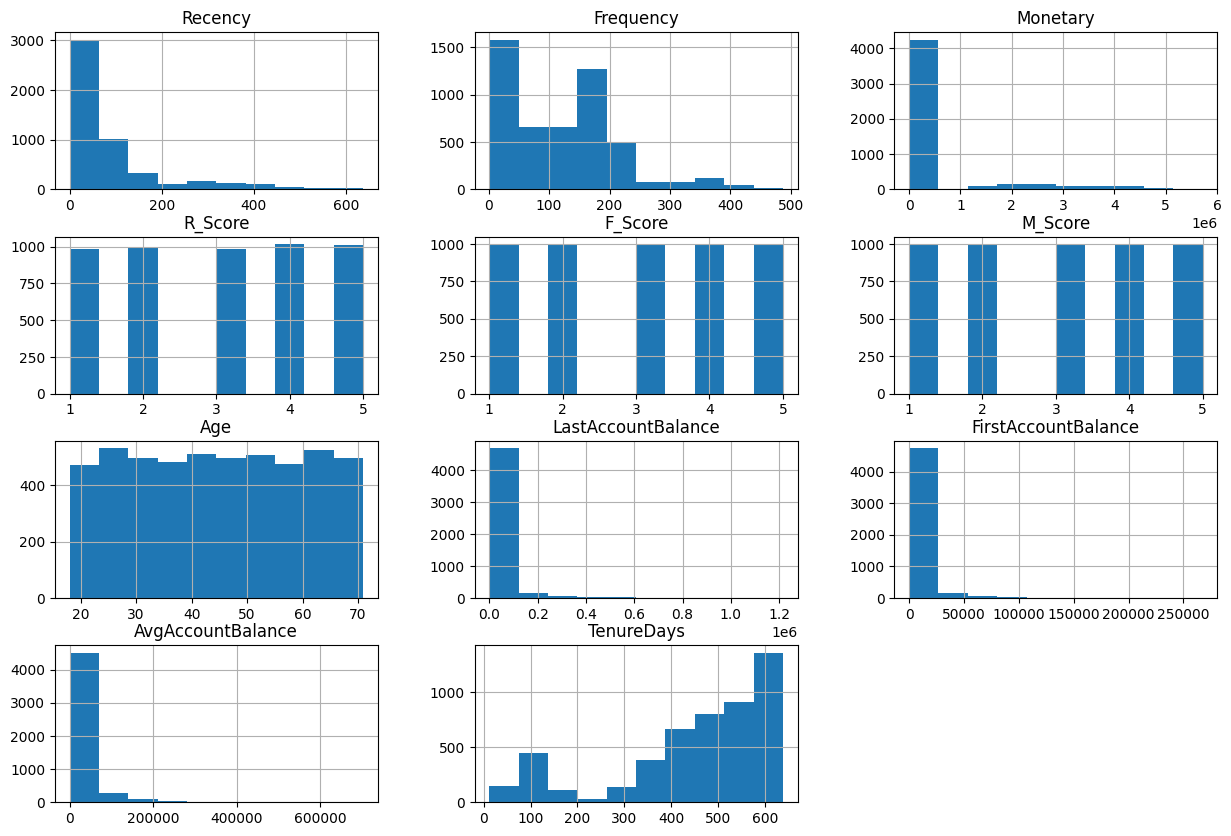

In [49]:
modelling_data.hist(figsize=(15, 10))

### Feature Selection and Transformation

Select the Recency, Frequency, and Monetary (RFM) features from `modelling_data` and create a copy to avoid modifying the original dataset.

### Log Transformation

Apply `np.log1p()` to Frequency and Monetary to reduce skewness and make their distributions more suitable for clustering. Recency is also log-transformed in this implementation, despite the comment indicating otherwise. `np.log1p()` computes \(\log(1+x)\), allowing zero values to be handled safely.

### Feature Standardisation

Use `StandardScaler()` to standardise the three features so they have a mean of approximately 0 and a standard deviation of approximately 1. This prevents features with larger numerical ranges from disproportionately influencing the clustering algorithm.

### Scaling the Features

Apply `fit_transform()` to learn the scaling parameters from the selected features and transform them into a standardised numerical array, `X_scaled`, ready for clustering.

In [50]:
X = modelling_data[["Recency", "Frequency", "Monetary"]].copy()

# Log-transform the skewed features (Recency stays raw)
X["Recency"]  = np.log1p(X["Recency"])
X["Frequency"] = np.log1p(X["Frequency"])
X["Monetary"]  = np.log1p(X["Monetary"])

# Standardise so all three features contribute equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


array([[<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>, <Axes: >]], dtype=object)

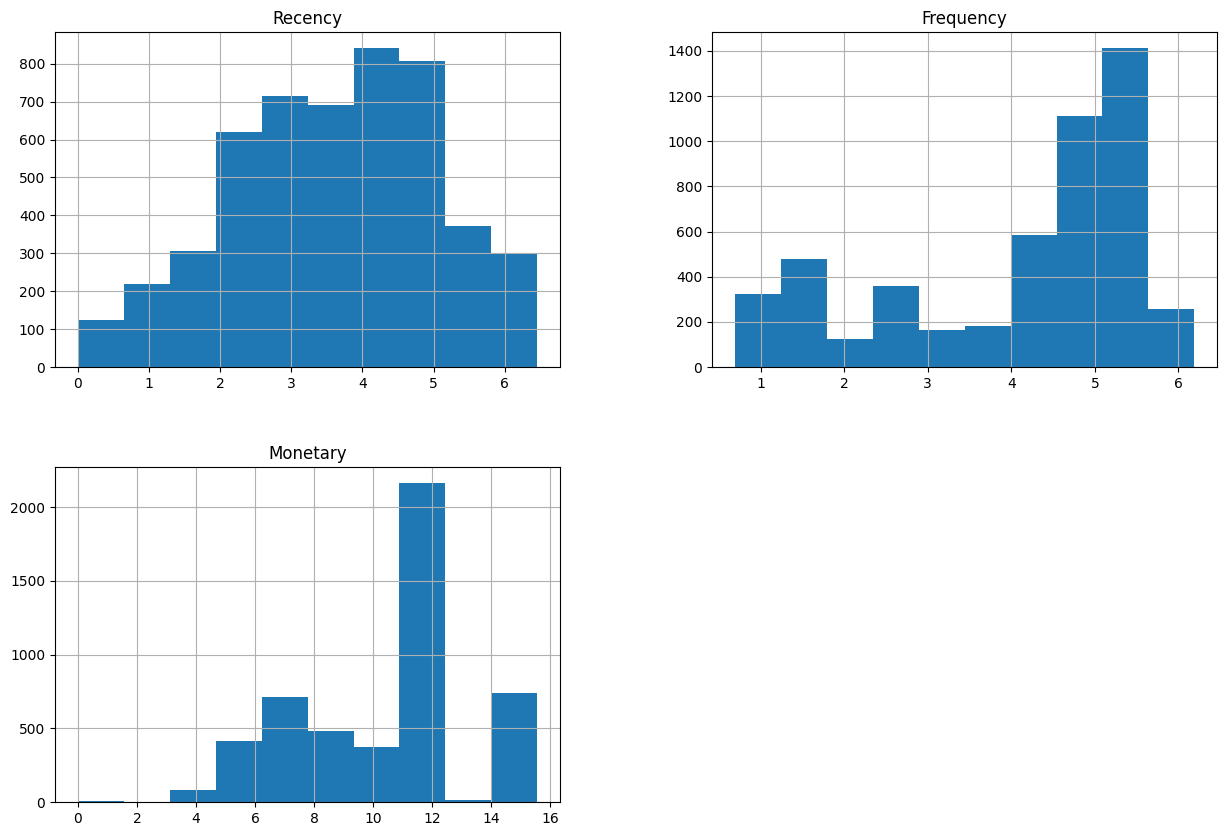

In [51]:
X.hist(figsize=(15, 10))

### Determine the Optimal Number of Clusters Using the Elbow Method

**1. Evaluate Different Numbers of Clusters**

Test values of *k* ranging from 2 to 10. For each value, fit a K-Means clustering model and record its inertia.

**2. Understanding Inertia**

Inertia measures how closely customers are grouped around the centre of their assigned clusters. In this project, it indicates how similar customers are to others within the same segment based on their Recency, Frequency, and Monetary values.

A **lower inertia** means customers are generally closer to their assigned cluster centres. However, inertia naturally decreases as the number of clusters increases, so the lowest inertia does not necessarily indicate the most suitable model.

**3. Generate and Interpret the Elbow Plot**

Use Plotly to visualise the relationship between the number of clusters (*k*) on the x-axis and inertia on the y-axis.

- **Look for the elbow:** Identify the point where the curve changes from a steep decline to a more gradual decline.
- **Before the elbow:** Adding clusters substantially reduces inertia, meaning customers are being grouped more closely.
- **After the elbow:** Adding more clusters produces smaller improvements in customer grouping while increasing the complexity of the segmentation.

**4. Select the Optimal Number of Clusters**

The point where the curve begins to flatten is a potential choice for the optimal number of clusters. For example, if the curve bends around *k* = 4, four customer segments may provide a reasonable balance between compact clusters and model simplicity.

The elbow is a guide rather than a guaranteed answer. Confirm the selection by considering the silhouette score, the sizes of the resulting customer segments, and whether the segments have meaningful business interpretations.

In [52]:
k_range = range(2, 11)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(k_range), y=inertias,
    mode="lines+markers",
    marker=dict(size=10),
    line=dict(width=3),
    hovertemplate="k = %{x}<br>Inertia = %{y:,.0f}<extra></extra>",
))
fig.update_layout(
    title="Elbow Plot — Inertia vs Number of Clusters",
    xaxis_title="Number of clusters (k)",
    yaxis_title="Inertia (within-cluster sum of squares)",
    height=450,
)
fig.show()

### Evaluate Cluster Quality Using the Silhouette Score

**Calculate Silhouette Scores**

Evaluate each value of *k* from 2 to 10 by fitting a K-Means model and calculating its average silhouette score. A sample of 5,000 customers is used to calculate the score, which reduces computation time while providing an estimate of cluster quality.

**Understanding the Silhouette Score**

The silhouette score measures how well customers fit within their assigned clusters and how clearly they are separated from customers in other clusters.

- **Closer to 1:** Customers are well grouped within their own segments and well separated from other segments.
- **Around 0:** Customers are close to the boundary between two or more segments, indicating overlapping clusters.
- **Below 0:** Some customers may be closer to another cluster than the one they were assigned to.

**Interpret the Silhouette Plot**

The figure shows the average silhouette score for each number of clusters. The **higher the score, the better defined the clusters are according to this metric**.

Unlike the Elbow Method, where we look for a point where the curve begins to flatten, the Silhouette Method looks for the **highest point on the plot**. The value of *k* corresponding to this highest point represents the number of clusters with the strongest overall separation and cohesion based on the silhouette measure.

**Identify the Best Number of Clusters**

The code uses `np.argmax()` to locate the highest silhouette score and assigns its corresponding number of clusters to `best_k`. The selected *k* can then be compared with the result from the Elbow Method before making the final clustering decision.

In [53]:
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=5000, random_state=RANDOM_STATE)
    sil_scores.append(score)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(k_range), y=sil_scores,
    mode="lines+markers",
    marker=dict(size=10),
    line=dict(width=3, color="#ff7f0e"),
    hovertemplate="k = %{x}<br>Silhouette = %{y:.4f}<extra></extra>",
))
fig.update_layout(
    title="Silhouette Score vs Number of Clusters",
    xaxis_title="Number of clusters (k)",
    yaxis_title="Average silhouette score",
    height=450,
)
fig.show()

# Print the best k by silhouette
best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette: {best_k} (score = {max(sil_scores):.4f})")

Best k by silhouette: 9 (score = 0.5595)


In [54]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Elbow — inertia vs k", "Silhouette — separation vs k"),
    horizontal_spacing=0.15,
)

fig.add_trace(
    go.Scatter(x=list(k_range), y=inertias, mode="lines+markers",
               marker=dict(size=10), line=dict(width=3),
               name="Inertia"),
    row=1, col=1,
)
fig.add_trace(
    go.Scatter(x=list(k_range), y=sil_scores, mode="lines+markers",
               marker=dict(size=10), line=dict(width=3, color="#ff7f0e"),
               name="Silhouette"),
    row=1, col=2,
)

fig.update_xaxes(title_text="k", row=1, col=1)
fig.update_xaxes(title_text="k", row=1, col=2)
fig.update_yaxes(title_text="Inertia", row=1, col=1)
fig.update_yaxes(title_text="Silhouette", row=1, col=2)

fig.update_layout(height=450, showlegend=False,
                  title_text="K-Means Diagnostics — Choosing k")
fig.show()

In [55]:
CHOSEN_K = 9   # ← change based on the elbow + silhouette

km_final = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=10)
modelling_data["Cluster"] = km_final.fit_predict(X_scaled)

# Final silhouette for the chosen k
final_sil = silhouette_score(X_scaled, modelling_data["Cluster"],
                             sample_size=5000, random_state=RANDOM_STATE)
print(f"Final model: k = {CHOSEN_K}, silhouette = {final_sil:.4f}")
print(f"Inertia: {km_final.inertia_:,.0f}")

Final model: k = 9, silhouette = 0.5595
Inertia: 921


then this:
CHOSEN_K = 5   # ← change based on the elbow + silhouette

km_final = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=10)
modelling_data["Cluster"] = km_final.fit_predict(X_scaled)

# Final silhouette for the chosen k
final_sil = silhouette_score(X_scaled, modelling_data["Cluster"],
                             sample_size=5000, random_state=RANDOM_STATE)
print(f"Final model: k = {CHOSEN_K}, silhouette = {final_sil:.4f}")
print(f"Inertia: {km_final.inertia_:,.0f}")
Final model: k = 9, silhouette = 0.5595
Inertia: 921

In [56]:
profile = (modelling_data
           .groupby("Cluster")
           .agg(Customers=("CustomerID", "count"),
                Recency=("Recency", "mean"),
                Frequency=("Frequency", "mean"),
                Monetary=("Monetary", "mean"),
                AvgR=("R_Score", "mean"),
                AvgF=("F_Score", "mean"),
                AvgM=("M_Score", "mean"))
           .round(2)
           .sort_values("Monetary", ascending=False))

profile["CustomerShare%"] = (100 * profile["Customers"] / profile["Customers"].sum()).round(2)
profile["RevenueShare%"]  = (100 * (profile["Monetary"] * profile["Customers"])
                             / (profile["Monetary"] * profile["Customers"]).sum()).round(2)

print(profile.to_string())

         Customers  Recency  Frequency     Monetary  AvgR  AvgF  AvgM  CustomerShare%  RevenueShare%
Cluster                                                                                             
3              272     4.03     349.70 4,054,582.77  4.95  4.93  5.00            5.44          45.64
0              480    70.23      66.22 2,244,210.10  2.44  2.33  5.00            9.61          44.58
2             1294    17.84     166.73   107,832.14  3.97  3.92  3.85           25.90           5.77
7              490     2.97     177.24   103,984.02  5.00  4.13  3.72            9.81           2.11
6              749   113.22     166.23    56,624.73  1.71  3.97  2.68           14.99           1.76
5              283    50.26      54.08     6,585.19  2.90  2.14  2.00            5.66           0.08
8               64     4.31      24.69     2,831.57  4.91  1.73  1.64            1.28           0.01
1              613    51.11      12.78     1,913.81  2.84  1.62  1.62           12.27      

### Profile and Name Customer Segments

**Create Cluster Profiles**

Group customers by their assigned cluster and calculate the number of customers along with the average Recency, Frequency, and Monetary values for each cluster. This provides a summary of the typical customer behaviour within each cluster.

**Define Business-Based Segment Names**

Create rules based on the RFM characteristics of each cluster to assign meaningful business names. These names translate the numerical K-Means clusters into customer segments that are easier to understand and use for business decision-making.

The segment names include **Champions, High-Value At Risk, Active Loyal, Loyal Customers, Dormant / Lost, At Risk, Emerging Customers, Low-Value Customers,** and **Occasional Customers**.

**Map Segment Names to Customers**

Create a mapping between each numerical cluster and its corresponding business segment name. The resulting segment name is then added to `modelling_data` as the `Segment` column.

**Review the Segment Profiles**

Print the final cluster profile showing the number of customers and their average Recency, Frequency, Monetary values, and assigned segment name. This allows the characteristics of each customer segment to be reviewed and validated before proceeding to the business interpretation and recommendations.

In [ ]:
import numpy as np
import pandas as pd

profile = modelling_data.groupby("Cluster").agg(Customers=("CustomerID", "count"),
                                                 Recency=("Recency", "mean"),
                                                   Frequency=("Frequency", "mean"), \
                                                    Monetary=("Monetary", "mean")).reset_index()

def name_cluster(row):
    r = row["Recency"]
    f = row["Frequency"]
    m = row["Monetary"]

    if r <= 15 and f >= 300 and m >= 1_000_000:
        return "Champions"
    elif m >= 1_000_000 and r > 15:
        return "High-Value At Risk"
    elif r <= 10 and f >= 150:
        return "Active Loyal"
    elif r <= 30 and f >= 150:
        return "Loyal Customers"
    elif r > 180 and f < 20:
        return "Dormant / Lost"
    elif r > 60 and f >= 100:
        return "At Risk"
    elif r <= 30 and f < 100:
        return "Emerging Customers"
    elif f < 20 and m < 5_000:
        return "Low-Value Customers"
    elif r <= 180:
        return "Occasional Customers"
    else:
        return "Dormant / Lost"

profile["SegmentName"] = profile.apply(name_cluster, axis=1)

cluster_to_name = dict(zip(profile["Cluster"], profile["SegmentName"]))

modelling_data["Segment"] = modelling_data["Cluster"].map(cluster_to_name)

print(profile[["Cluster", "Customers", "Recency", "Frequency", "Monetary", "SegmentName"]].round(2).sort_values("Cluster").to_string(index=False))

 Cluster  Customers  Recency  Frequency     Monetary          SegmentName
       0        480    70.23      66.22 2,244,210.10   High-Value At Risk
       1        613    51.11      12.78     1,913.81  Low-Value Customers
       2       1294    17.84     166.73   107,832.14      Loyal Customers
       3        272     4.03     349.70 4,054,582.77            Champions
       4        752   314.48       2.97       480.54       Dormant / Lost
       5        283    50.26      54.08     6,585.19 Occasional Customers
       6        749   113.22     166.23    56,624.73              At Risk
       7        490     2.97     177.24   103,984.02         Active Loyal
       8         64     4.31      24.69     2,831.57   Emerging Customers


### Generate Customer Segment Summary

**Aggregate Segment-Level Metrics**

Group customers by their assigned business segment and calculate the number of customers along with the average Recency, Frequency, and Monetary values for each segment. This provides an overall view of customer behaviour across the identified segments.

**Calculate Customer Share**

Calculate each segment's percentage of the total customer base. This shows how large each segment is relative to the overall customer population.

**Calculate Segment Revenue**

Calculate the total Monetary value contributed by customers within each segment. This helps identify the segments that generate the largest overall customer value.

**Calculate Revenue Share**

Calculate each segment's percentage contribution to the total Monetary value across all customers. Comparing **Customer Share%** with **Revenue Share%** helps identify segments that represent a large portion of the customer base but contribute relatively little value, as well as smaller segments that contribute disproportionately high value.

**Sort and Review the Segment Summary**

Sort the segments by total Monetary value in descending order and display the final summary. The resulting table provides a consolidated view of **customer size, purchasing behaviour, customer share, revenue contribution, and revenue share** for each segment.

In [58]:
segment_summary = (modelling_data
                   .groupby("Segment")
                   .agg(Customers=("CustomerID", "count"),
                        Recency=("Recency", "mean"),
                        Frequency=("Frequency", "mean"),
                        Monetary=("Monetary", "mean"))
                   .round(2)
                   .sort_values("Monetary", ascending=False))

segment_summary["CustomerShare%"] = (
    100 * segment_summary["Customers"] / segment_summary["Customers"].sum()).round(2)

segment_summary["Revenue"] = (
    modelling_data.groupby("Segment")["Monetary"].sum().round(2))
segment_summary["RevenueShare%"] = (
    100 * segment_summary["Revenue"] / segment_summary["Revenue"].sum()).round(2)

print(segment_summary.to_string())

                      Customers  Recency  Frequency     Monetary  CustomerShare%          Revenue  RevenueShare%
Segment                                                                                                         
Champions                   272     4.03     349.70 4,054,582.77            5.44 1,102,846,513.47          45.64
High-Value At Risk          480    70.23      66.22 2,244,210.10            9.61 1,077,220,847.00          44.58
Loyal Customers            1294    17.84     166.73   107,832.14           25.90   139,534,792.55           5.77
Active Loyal                490     2.97     177.24   103,984.02            9.81    50,952,170.57           2.11
At Risk                     749   113.22     166.23    56,624.73           14.99    42,411,922.62           1.76
Occasional Customers        283    50.26      54.08     6,585.19            5.66     1,863,608.08           0.08
Emerging Customers           64     4.31      24.69     2,831.57            1.28       181,220.4

In [59]:
modelling_data.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,CustomerDOB,CustGender,CustLocation,Age,LastAccountBalance,FirstAccountBalance,AvgAccountBalance,FirstTransaction,LastTransaction,TenureDays,Cluster,Segment
0,CUST00001,111,168,"51,269.29",2,4,3,2007-04-30,Male,London,19.40,615.11,"4,716.01","1,255.05",2024-12-13,2026-05-24,638,6,At Risk
1,CUST00002,19,196,"154,678.49",4,5,5,1961-08-07,Male,Newcastle,65.10,584.49,"10,949.29","3,258.89",2024-12-19,2026-08-24,632,2,Loyal Customers
2,CUST00003,97,149,"58,059.69",2,3,3,2006-09-02,Male,Leeds,20.00,"6,344.00","3,917.39","4,830.30",2025-01-27,2026-06-07,593,6,At Risk
3,CUST00004,14,103,"64,212.54",4,3,3,1975-11-21,Male,Birmingham,50.80,821.46,"3,243.81","1,560.26",2025-09-04,2026-08-29,373,2,Loyal Customers
4,CUST00005,72,157,"43,112.11",2,4,2,1962-10-31,Female,Liverpool,63.90,"1,554.08","2,230.21","1,288.83",2025-01-08,2026-07-02,612,6,At Risk


### Visualise Customer Segment Distribution

**Prepare Segment Counts**

Count the number of customers belonging to each business segment and organise the results into a summary containing the segment name and customer count.

**Create the Segment Overview**

Create a two-part visualisation to show the distribution of customers across the identified segments.

**Customer Count per Segment**

The bar chart displays the **number of customers in each segment**, making it easy to compare the size of the segments and identify which segments contain the largest and smallest customer populations.

**Segment Share of Customers**

The donut chart shows the **percentage contribution of each segment to the total customer base**. This provides a clearer view of how the overall customer population is distributed across the different segments.

**Interpret the Visualisation**

Together, the two charts provide both the **actual customer count** and the **relative share** of each segment. This helps determine whether the customer base is concentrated in a few segments or distributed relatively evenly across the identified customer groups.

In [60]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Data
seg_counts = modelling_data["Segment"].value_counts().reset_index()
seg_counts.columns = ["Segment", "Customers"]

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "domain"}]],
    subplot_titles=("Customer Count per Segment", "Segment Share of Customers"),
    horizontal_spacing=0.12,
)

# 1a — Bar
fig.add_trace(
    go.Bar(
        x=seg_counts["Segment"], y=seg_counts["Customers"],
        marker_color=px.colors.qualitative.Bold[:len(seg_counts)],
        text=seg_counts["Customers"], textposition="outside",
        showlegend=False, name="Customers",
    ),
    row=1, col=1,
)

# 1b — Pie (donut)
fig.add_trace(
    go.Pie(
        labels=seg_counts["Segment"], values=seg_counts["Customers"],
        hole=0.5, textinfo="label+percent",
        marker=dict(colors=px.colors.qualitative.Bold),
        showlegend=False,
    ),
    row=1, col=2,
)

fig.update_xaxes(tickangle=-25, row=1, col=1)
fig.update_layout(height=480, title_text="Segment Overview")
fig.show()

### Analyse Segment Behaviour and Demographics

**Create Segment Profiles**

Calculate the average **Recency, Frequency, Monetary value, and Age** for each customer segment. This provides a behavioural and demographic profile of the customers within each segment.

**Calculate Revenue Contribution**

Calculate the total Monetary value generated by each segment to determine each segment's contribution to overall customer revenue.

**Analyse Gender Composition**

Group customers by segment and gender to determine the number of male and female customers within each segment. This provides insight into the demographic composition of the customer segments.

**Create the Segment Behaviour and Demographics Dashboard**

Create a four-part visualisation to examine different characteristics of the customer segments:

- **Revenue Share per Segment:** Shows the proportion of total revenue contributed by each customer segment.
- **Average Recency / Frequency per Segment:** Compares the average number of days since the last transaction and the average number of transactions across segments.
- **Gender Composition per Segment:** Shows the distribution of customers by gender within each segment.
- **Average Age per Segment:** Compares the average age of customers across the different segments.

**Interpret the Visualisation**

The combined visualisation provides a broader understanding of **customer value, purchasing behaviour, and demographics** across the segments. It can be used to identify differences in customer activity, revenue contribution, age, and gender composition between segments.

In [61]:
seg_profile = (modelling_data
               .groupby("Segment")
               .agg(Recency=("Recency", "mean"),
                    Frequency=("Frequency", "mean"),
                    Monetary=("Monetary", "mean"),
                    Age=("Age", "mean"))
               .reset_index())

rev_by_seg = (modelling_data
              .groupby("Segment")["Monetary"].sum()
              .reset_index())

gender_seg = (modelling_data
              .groupby(["Segment", "CustGender"])
              .size().reset_index(name="Count"))

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "domain"}, {"type": "xy"}],
           [{"type": "xy"},     {"type": "xy"}]],
    subplot_titles=("Revenue Share per Segment",
                    "Avg Recency / Frequency per Segment",
                    "Gender Composition per Segment",
                    "Average Age per Segment"),
    horizontal_spacing=0.12, vertical_spacing=0.18,
)

# 2a — Donut: revenue share
fig.add_trace(
    go.Pie(
        labels=rev_by_seg["Segment"], values=rev_by_seg["Monetary"],
        hole=0.55, textinfo="label+percent",
        marker=dict(colors=px.colors.qualitative.Bold),
        showlegend=False,
    ),
    row=1, col=1,
)

# 2b — Grouped bar: Recency + Frequency (single plot, two traces)
fig.add_trace(
    go.Bar(
        x=seg_profile["Segment"], y=seg_profile["Recency"],
        name="Avg Recency (days)",
        marker_color=px.colors.qualitative.Bold[0],
    ),
    row=1, col=2,
)
fig.add_trace(
    go.Bar(
        x=seg_profile["Segment"], y=seg_profile["Frequency"],
        name="Avg Frequency",
        marker_color=px.colors.qualitative.Bold[1],
        yaxis="y2",
    ),
    row=1, col=2,
)

# 2c — Grouped bar: gender
for i, gender in enumerate(gender_seg["CustGender"].unique()):
    sub = gender_seg[gender_seg["CustGender"] == gender]
    fig.add_trace(
        go.Bar(
            x=sub["Segment"], y=sub["Count"], name=gender,
            marker_color=px.colors.qualitative.Bold[i],
        ),
        row=2, col=1,
    )

# 2d — Bar: average age
fig.add_trace(
    go.Bar(
        x=seg_profile["Segment"], y=seg_profile["Age"],
        marker_color=px.colors.qualitative.Bold[2],
        text=seg_profile["Age"].round(1), textposition="outside",
        showlegend=False, name="Avg Age",
    ),
    row=2, col=2,
)

fig.update_layout(
    height=800, barmode="group",
    title_text="Segment Behaviour and Demographics",
    legend=dict(orientation="h", yanchor="bottom", y=1.02,
                xanchor="right", x=1),
)
fig.update_xaxes(tickangle=-25)
fig.show()

### Analyse Value Concentration, Geography, and Account Balance

**Identify Top Customers**

Sort customers by their Monetary value in descending order and select the top 10 customers. This identifies the customers with the highest transaction value in the dataset.

**Analyse Customer Locations**

Count customers by location and select the five locations with the highest number of customers. This provides an overview of where the customer base is most concentrated geographically.

**Analyse Average Account Balance**

Calculate the average `LastAccountBalance` for each customer segment and sort the segments from the highest to the lowest average balance. This helps compare the financial position of customers across segments.

**Create the Value Concentration, Geography, and Balance Dashboard**

Create a four-part visualisation to examine customer value and account characteristics:

- **Top 10 Customers by Revenue:** Shows the customers with the highest Monetary values.
- **Top 5 Customer Locations:** Shows the proportion of customers belonging to the five most common customer locations.
- **Cumulative Revenue Within Each Segment:** Shows how quickly each segment's total revenue accumulates as customers are ordered from the highest to the lowest Monetary value. This helps identify whether a segment's revenue is concentrated among a relatively small number of high-value customers.
- **Average Account Balance per Segment:** Compares the average account balance across the different customer segments.

**Interpret the Visualisation**

The dashboard provides a deeper view of **value concentration, customer geography, and financial position**. It helps identify high-value individual customers, locations with larger customer populations, segments where revenue may be concentrated among fewer customers, and segments with higher average account balances.

In [62]:
top10 = modelling_data.sort_values("Monetary", ascending=False).head(10)

loc_counts = modelling_data["CustLocation"].value_counts().head(5).reset_index()
loc_counts.columns = ["Location", "Customers"]

bal_seg = (modelling_data
           .groupby("Segment")["LastAccountBalance"]
           .mean().reset_index()
           .sort_values("LastAccountBalance", ascending=False))

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "xy"},     {"type": "domain"}],
           [{"type": "xy"},     {"type": "xy"}]],
    subplot_titles=("Top 10 Customers by Revenue",
                    "Top 5 Customer Locations",
                    "Cumulative Revenue Within Each Segment",
                    "Avg Account Balance per Segment"),
    horizontal_spacing=0.12, vertical_spacing=0.20,
)

# 3a — Bar: top 10 customers
fig.add_trace(
    go.Bar(
        x=top10["CustomerID"], y=top10["Monetary"],
        marker_color=[px.colors.qualitative.Bold[
            list(modelling_data["Segment"].unique()).index(s) % 10]
            for s in top10["Segment"]],
        text=top10["Monetary"].apply(lambda v: f"£{v/1e3:,.0f}k"),
        textposition="outside",
        showlegend=False,
    ),
    row=1, col=1,
)

# 3b — Donut: locations
fig.add_trace(
    go.Pie(
        labels=loc_counts["Location"], values=loc_counts["Customers"],
        hole=0.5, textinfo="label+percent",
        marker=dict(colors=px.colors.qualitative.Bold),
        showlegend=False,
    ),
    row=1, col=2,
)

# 3c — Line: cumulative revenue within each segment
for i, seg in enumerate(modelling_data["Segment"].unique()):
    seg_data = (modelling_data[modelling_data["Segment"] == seg]
                .sort_values("Monetary", ascending=False))
    if len(seg_data) == 0:
        continue
    cumulative = seg_data["Monetary"].cumsum() / seg_data["Monetary"].sum() * 100
    cust_pct = np.arange(1, len(seg_data) + 1) / len(seg_data) * 100
    fig.add_trace(
        go.Scatter(
            x=cust_pct, y=cumulative, mode="lines", name=seg,
            line=dict(width=3, color=px.colors.qualitative.Bold[i % 10]),
        ),
        row=2, col=1,
    )

# 3d — Bar: avg balance per segment
fig.add_trace(
    go.Bar(
        x=bal_seg["Segment"], y=bal_seg["LastAccountBalance"],
        marker_color=px.colors.qualitative.Bold[:len(bal_seg)],
        text=bal_seg["LastAccountBalance"].apply(lambda v: f"£{v:,.0f}"),
        textposition="outside", showlegend=False,
    ),
    row=2, col=2,
)

fig.update_layout(
    height=850, title_text="Value Concentration, Geography, and Balance",
    legend=dict(orientation="h", yanchor="bottom", y=1.02,
                xanchor="right", x=1),
)
fig.update_xaxes(tickangle=-25)
fig.show()

In [63]:
transactions_with_segments = customer_transaction_data.merge(
    modelling_data[["CustomerID", "Segment"]],
    on="CustomerID",
    how="left",
)

print(transactions_with_segments.shape)
print(transactions_with_segments["Segment"].value_counts().to_string())

(580962, 23)
Segment
Loyal Customers         215748
At Risk                 124504
Champions                95119
Active Loyal             86848
High-Value At Risk       31788
Occasional Customers     15306
Low-Value Customers       7837
Dormant / Lost            2232
Emerging Customers        1580


### Prepare Transaction Behaviour Analysis

**Prepare Transaction-Level Segment Data**

Use the transaction dataset containing customer segment assignments. This connects individual transaction behaviour to the customer segments identified through the RFM clustering analysis.

**Analyse Transaction Type Mix**

Group transactions by customer segment and transaction type to determine the types of transactions most commonly performed within each segment.

**Analyse Wallet Activity**

Calculate the average wallet activity for each segment and convert the result into a percentage. This shows the proportion of customers or transactions associated with wallet activity across the different segments.

**Analyse Currency Mix**

Group transactions by segment and transaction currency to identify the currencies most commonly used by customers within each segment.

**Analyse Transaction Status**

Calculate the number and percentage of transactions for each transaction status within every customer segment. This allows transaction outcomes to be compared across segments.

**Analyse Transaction Activity by Hour**

Create a cross-tabulation of transaction hours and customer segments. This provides the data needed to examine when customers from different segments are most active.

**Prepare the Frequency vs Monetary Sample**

Create a random sample of up to 5,000 customers for visualising the relationship between transaction frequency and monetary value. Sampling limits the number of observations used in the visualisation while retaining a representative view of customer behaviour.

**Prepare the Analysis Outputs**

The resulting datasets — `type_mix`, `wallet_seg`, `cur_mix`, `status_mix`, `hour_seg`, and `scatter_sample` — provide the aggregated data required to analyse **transaction behaviour, wallet activity, currency usage, transaction outcomes, activity timing, and the relationship between customer frequency and monetary value** across the identified customer segments.

In [64]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# If you haven't already created this, run:
# transactions_with_segments = cleaned_customer_transaction.merge(
#     modelling_data[["CustomerID", "Segment"]], on="CustomerID", how="left")
# Otherwise, alias the existing table:
TXN = transactions_with_segments

# 1. Transaction type mix per segment
type_mix = (TXN
            .groupby(["Segment", "TransactionType"])
            .size().reset_index(name="Count"))

# 2. Wallet activity per segment
wallet_seg = (TXN
              .groupby("Segment")["WalletActivity"]
              .mean().mul(100).reset_index(name="WalletShare%"))

# 3. Currency mix per segment
cur_mix = (TXN
           .groupby(["Segment", "TransactionCurrency"])
           .size().reset_index(name="Count"))

# 4. Status mix per segment (as % of each segment)
status_mix = (TXN
              .groupby(["Segment", "TransactionStatus"])
              .size().reset_index(name="Count"))
status_mix["Pct"] = status_mix.groupby("Segment")["Count"].transform(
    lambda s: 100 * s / s.sum())

# 5. Hour × segment heatmap
hour_seg = pd.crosstab(TXN["Hour"], TXN["Segment"])

# 6. Scatter sample (Frequency vs Monetary)
scatter_sample = modelling_data.sample(
    min(5000, len(modelling_data)), random_state=42)

print("Aggregations ready:",
      "type_mix", "wallet_seg", "cur_mix",
      "status_mix", "hour_seg", "scatter_sample", sep=", ")

Aggregations ready:, type_mix, wallet_seg, cur_mix, status_mix, hour_seg, scatter_sample


### Visualise Transaction Type and Digital Activity by Segment

Create a two-part visualisation to compare transaction behaviour and digital activity across customer segments.

#### 1. Transaction Type Mix per Segment
- Display the number of transactions for each transaction type within every customer segment.
- Use a stacked bar chart so the overall transaction volume and the composition of transaction types can be compared across segments.
- Each colour represents a different transaction type.

#### 2. Digital / Crypto Activity per Segment
- Display the percentage of customers showing wallet activity within each segment.
- Use a bar chart to make differences in digital or crypto activity between segments easy to compare.
- The percentage value is displayed above each bar.

#### 3. Combined Visualisation
The two charts are presented side by side under the title **"Channel Mix and Digital Activity by Segment"**.

This visualisation helps identify how transaction types differ across customer segments and which segments show stronger levels of digital or crypto wallet activity.

In [65]:
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "xy"}]],
    subplot_titles=(
        "Transaction Type Mix per Segment",
        "Digital / Crypto Activity per Segment (%)",
    ),
    horizontal_spacing=0.12,
)

# 1. Transaction type mix (stacked bar)
for i, t in enumerate(type_mix["TransactionType"].unique()):
    sub = type_mix[type_mix["TransactionType"] == t]
    fig.add_trace(
        go.Bar(
            x=sub["Segment"], y=sub["Count"], name=t,
            legendgroup="type",
            marker_color=px.colors.qualitative.Bold[i % 10],
        ),
        row=1, col=1,
    )

# 2. Wallet share (bar)
fig.add_trace(
    go.Bar(
        x=wallet_seg["Segment"], y=wallet_seg["WalletShare%"],
        marker_color=px.colors.qualitative.Bold[2],
        text=wallet_seg["WalletShare%"].round(1),
        texttemplate="%{text}%", textposition="outside",
        showlegend=False,
    ),
    row=1, col=2,
)

fig.update_xaxes(tickangle=-25)
fig.update_layout(
    height=520,
    barmode="stack",
    title_text="Channel Mix and Digital Activity by Segment",
    legend=dict(orientation="h", yanchor="bottom", y=-0.25,
                xanchor="right", x=1, font=dict(size=10)),
)
fig.show()

### Visualise Currency and Transaction Status Behaviour by Segment

Create a two-part visualisation to compare currency usage and transaction outcomes across customer segments.

#### 1. Currency Mix per Segment
- Display the number of transactions for each transaction currency within every customer segment.
- Use a stacked bar chart to show both the total transaction volume and the composition of currencies used by each segment.
- Each colour represents a different transaction currency.

#### 2. Status Mix per Segment
- Display the percentage of transactions for each transaction status within every customer segment.
- Use a stacked bar chart so the overall status composition of each segment can be compared.
- The percentages show how transaction outcomes are distributed within each segment.

#### 3. Combined Visualisation
The two charts are presented side by side under the title **"Currency and Status Behaviour by Segment"**.

This visualisation helps identify differences in currency usage and transaction outcomes across customer segments.

In [66]:
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "xy"}]],
    subplot_titles=(
        "Currency Mix per Segment",
        "Status Mix per Segment (%)",
    ),
    horizontal_spacing=0.12,
)

# 3. Currency mix (stacked bar)
for i, c in enumerate(cur_mix["TransactionCurrency"].unique()):
    sub = cur_mix[cur_mix["TransactionCurrency"] == c]
    fig.add_trace(
        go.Bar(
            x=sub["Segment"], y=sub["Count"], name=c,
            legendgroup="currency",
            marker_color=px.colors.qualitative.Bold[i % 10],
        ),
        row=1, col=1,
    )

# 4. Status mix (stacked bar, as %)
for i, s in enumerate(status_mix["TransactionStatus"].unique()):
    sub = status_mix[status_mix["TransactionStatus"] == s]
    fig.add_trace(
        go.Bar(
            x=sub["Segment"], y=sub["Pct"], name=s,
            legendgroup="status",
            marker_color=px.colors.qualitative.Bold[i % 10],
        ),
        row=1, col=2,
    )

fig.update_xaxes(tickangle=-25)
fig.update_layout(
    height=520,
    barmode="stack",
    title_text="Currency and Status Behaviour by Segment",
    legend=dict(orientation="h", yanchor="bottom", y=-0.25,
                xanchor="right", x=1, font=dict(size=10)),
)
fig.show()

### Visualise Transaction Timing and Segment-Level RFM Behaviour

Create a two-part visualisation to examine when customers transact and compare average purchasing behaviour across customer segments.

#### 1. Transaction Volume by Hour and Segment
- Calculate the number of transactions for each hour of the day within every customer segment.
- Use a grouped bar chart to compare transaction activity across segments throughout the day.
- This helps identify periods when different customer segments are more active.

#### 2. Average Frequency and Monetary per Segment
- Calculate the average Frequency and Monetary values for each customer segment.
- Display both metrics using a bar chart with a logarithmic y-axis because Frequency and Monetary can have substantially different scales.
- Display formatted values above each bar for easier interpretation.

#### 3. Combined Visualisation
The two charts are presented side by side under the title **"When Customers Transact and Segment Averages"**.

This visualisation helps identify **when customers transact** and how purchasing frequency and monetary value differ across the customer segments.

In [67]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# --- Prep ---
hour_long = (transactions_with_segments
             .groupby(["Hour", "Segment"])
             .size()
             .reset_index(name="Count"))

rfm_by_seg = (modelling_data
              .groupby("Segment", as_index=False)
              .agg(Frequency=("Frequency", "mean"),
                   Monetary=("Monetary", "mean")))

# --- Formatters ---
def format_money(v):
    if v >= 1_000_000:
        return f"£{v/1_000_000:,.1f}M"
    if v >= 1_000:
        return f"£{v/1_000:,.0f}k"
    return f"£{v:,.0f}"

def format_count(v):
    return f"{v:,.0f}"

# --- Figure ---
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "xy"}]],
    subplot_titles=(
        "Transaction Volume by Hour and Segment",
        "Avg Frequency and Monetary per Segment",
    ),
    horizontal_spacing=0.12,
)

# 1. Hour × segment — grouped bar
for i, seg in enumerate(hour_long["Segment"].unique()):
    sub = hour_long[hour_long["Segment"] == seg]
    fig.add_trace(
        go.Bar(
            x=sub["Hour"], y=sub["Count"], name=seg,
            legendgroup=seg,
            marker_color=px.colors.qualitative.Bold[i % 10],
        ),
        row=1, col=1,
    )

# 2. Frequency + Monetary per segment — single log axis
for i, metric in enumerate(["Frequency", "Monetary"]):
    text_values = rfm_by_seg[metric].apply(
        lambda v: format_count(v) if metric == "Frequency" else format_money(v))
    fig.add_trace(
        go.Bar(
            x=rfm_by_seg["Segment"], y=rfm_by_seg[metric],
            name=f"Avg {metric}",
            legendgroup=metric,
            marker_color=px.colors.qualitative.Bold[i],
            text=text_values,
            textposition="outside",
        ),
        row=1, col=2,
    )

# --- Layout ---
fig.update_xaxes(title="Hour of day", dtick=2, row=1, col=1)
fig.update_yaxes(title="Transaction count", row=1, col=1)
fig.update_xaxes(tickangle=-25, row=1, col=2)
fig.update_yaxes(type="log", title="Value (log scale)", row=1, col=2)

fig.update_layout(
    height=560,
    barmode="group",
    title_text="When Customers Transact and Segment Averages",
    legend=dict(orientation="h", yanchor="bottom", y=-0.30,
                xanchor="right", x=1, font=dict(size=10)),
)
fig.show()